# Common mammalian species across gene spectra

This compact notebook reports **inclusive** intersections: a species shared by four genes is also counted in every relevant pair and triple. Presence means that a complete 12-component spectrum is available, not merely that a gene sequence exists.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_project_root(start=Path.cwd()):
    """Find the repository from either its root or notebooks/."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "scripts" / "count_common_species.py").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the project root")


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts import count_common_species as overlap

TARGET_CLASS = "Mammalia"
MAX_COMBINATION_SIZE = 4
sns.set_theme(style="white", context="notebook")

In [2]:
profiles = overlap.load_gene_species_profiles(
    overlap.DEFAULT_INPUT, TARGET_CLASS
)
species_by_gene = overlap.build_species_sets(profiles)
gene_summary = overlap.make_gene_summary(species_by_gene)
intersection_counts, intersection_members = overlap.count_intersections(
    species_by_gene, MAX_COMBINATION_SIZE
)

print("Usable spectra per gene")
display(gene_summary.reset_index(drop=True))
print("Inclusive intersections")
display(
    intersection_counts.sort_values(
        ["combination_size", "n_common_species", "genes"],
        ascending=[True, False, True],
    ).reset_index(drop=True).round({"jaccard_index": 3})
)

Usable spectra per gene


,gene,n_species
0,Cytb,791
1,ND2,126
2,CO1,112
3,CO3,71


Inclusive intersections


,combination_size,genes,n_common_species,n_union_species,jaccard_index
0,2,CO1 + Cytb,104,799,0.130
1,2,Cytb + ND2,100,817,0.122
2,2,CO1 + ND2,75,163,0.460
3,2,CO3 + Cytb,62,800,0.078
4,2,CO3 + ND2,57,140,0.407
5,2,CO1 + CO3,53,130,0.408
6,3,CO1 + Cytb + ND2,71,821,0.086
7,3,CO3 + Cytb + ND2,55,824,0.067
8,3,CO1 + CO3 + Cytb,52,807,0.064
9,3,CO1 + CO3 + ND2,51,175,0.291


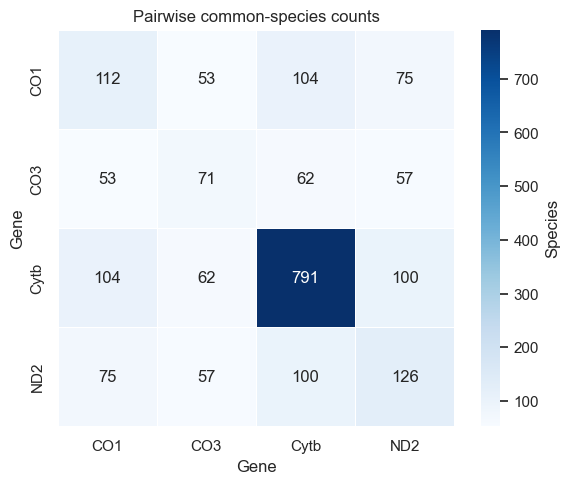

In [3]:
genes = sorted(species_by_gene)
pairwise = pd.DataFrame(index=genes, columns=genes, dtype=int)
for gene_a in genes:
    for gene_b in genes:
        pairwise.loc[gene_a, gene_b] = len(
            species_by_gene[gene_a] & species_by_gene[gene_b]
        )

fig, ax = plt.subplots(figsize=(6.2, 5.0))
sns.heatmap(
    pairwise.astype(int), annot=True, fmt="d", cmap="Blues",
    square=True, linewidths=0.5, cbar_kws={"label": "Species"}, ax=ax,
)
ax.set_title("Pairwise common-species counts")
ax.set(xlabel="Gene", ylabel="Gene")
fig.tight_layout()
plt.show()

In [4]:
def common_count(*genes):
    if not set(genes).issubset(species_by_gene):
        return None
    return len(set.intersection(*(species_by_gene[g] for g in genes)))

requested_comparisons = pd.DataFrame(
    [
        {"genes": "CO3 + ND6", "n_common_species": common_count("CO3", "ND6"),
         "note": "ND6 has no spectrum in the 12-component input"},
        {"genes": "CO1 + Cytb", "n_common_species": common_count("CO1", "Cytb"),
         "note": "Available requested comparison"},
        {"genes": "CO3 + ND2", "n_common_species": common_count("CO3", "ND2"),
         "note": "Diagnostic only; ND2 is not ND6"},
        {"genes": "CO1 + CO3 + Cytb", "n_common_species": common_count("CO1", "CO3", "Cytb"),
         "note": "Matched cohort used for the TSSS notebook"},
    ]
)
display(requested_comparisons)

,genes,n_common_species,note
0,CO3 + ND6,NaN,ND6 has no spectrum in the 12-component input
1,CO1 + Cytb,104.0,Available requested comparison
2,CO3 + ND2,57.0,Diagnostic only; ND2 is not ND6
3,CO1 + CO3 + Cytb,52.0,Matched cohort used for the TSSS notebook
